<a href="https://colab.research.google.com/github/shreyakiyoor/Keras/blob/master/CNN_Lesson_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy,binary_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix

import glob
from google.colab import drive
import os
import random
import shutil

import matplotlib.pyplot as plt
import seaborn as sns


from io import BytesIO
from PIL import Image


import pandas as pd
import numpy as np
from tqdm import tqdm

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
for file_path in os.listdir("/content/drive/MyDrive/Problems/CNN/Data/cat_data/"):
    final_path = "/content/drive/MyDrive/Problems/CNN/Data/cat_data/" + str(file_path)
    if os.path.getsize(final_path) == 0:
      print(f"\n {final_path}")
      os.remove(final_path)

for file_path in os.listdir("/content/drive/MyDrive/Problems/CNN/Data/dog_data/"):
    final_path = "/content/drive/MyDrive/Problems/CNN/Data/dog_data/" + str(file_path)
    if os.path.getsize(final_path) == 0:
      print(f"\n {final_path}")
      os.remove(final_path)


In [ ]:
if not os.path.isdir("train/cat"):
  os.makedirs("/content/drive/MyDrive/Problems/CNN/Data/train/dogs")
  os.makedirs("/content/drive/MyDrive/Problems/CNN/Data/train/cats")
  os.makedirs("/content/drive/MyDrive/Problems/CNN/Data/valid/dogs")
  os.makedirs("/content/drive/MyDrive/Problems/CNN/Data/valid/cats")
  os.makedirs("/content/drive/MyDrive/Problems/CNN/Data/test/dogs")
  os.makedirs("/content/drive/MyDrive/Problems/CNN/Data/test/cats")


  for c in random.sample(glob.glob("/content/drive/MyDrive/Problems/CNN/Data/cat_data/*"),3000):
    shutil.copy(c,"/content/drive/MyDrive/Problems/CNN/Data/train/cats")
  for c in random.sample(glob.glob("/content/drive/MyDrive/Problems/CNN/Data/dog_data/*"),3000):
    shutil.copy(c,"/content/drive/MyDrive/Problems/CNN/Data/train/dogs")
  for c in random.sample(glob.glob("/content/drive/MyDrive/Problems/CNN/Data/cat_data/*"),500):
    shutil.copy(c,"/content/drive/MyDrive/Problems/CNN/Data/valid/cats")
  for c in random.sample(glob.glob("/content/drive/MyDrive/Problems/CNN/Data/dog_data/*"),500):
    shutil.copy(c,"/content/drive/MyDrive/Problems/CNN/Data/valid/dogs")
  for c in random.sample(glob.glob("/content/drive/MyDrive/Problems/CNN/Data/cat_data/*"),50):
    shutil.copy(c,"/content/drive/MyDrive/Problems/CNN/Data/test/cats")
  for c in random.sample(glob.glob("/content/drive/MyDrive/Problems/CNN/Data/dog_data/*"),50):
    shutil.copy(c,"/content/drive/MyDrive/Problems/CNN/Data/test/dogs")


In [ ]:
train_path = "/content/drive/MyDrive/Problems/CNN/Data/train/"
valid_path  = "/content/drive/MyDrive/Problems/CNN/Data/valid/"
test_path = "/content/drive/MyDrive/Problems/CNN/Data/test/"

In [ ]:
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory = train_path,target_size = (224,224),batch_size = 10,classes = ['cats','dogs'])
valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory = valid_path,target_size = (224,224),batch_size = 10,classes = ['cats','dogs'])
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory = test_path,target_size = (224,224),batch_size = 10,classes = ['cats','dogs'])



Found 6000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
# train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory = train_path,target_size = (224,224),batch_size = 10,class_mode = 'binary')
# valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory = valid_path,target_size = (224,224),batch_size = 10,class_mode = 'binary')
# test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(directory = test_path,target_size = (224,224),batch_size = 10,class_mode = 'binary')



Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


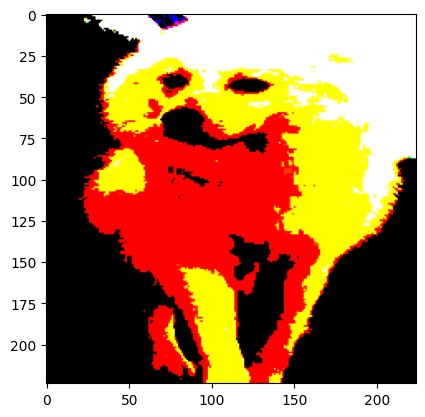

In [ ]:
plt.imshow(train_batches[0][0][0])

## Custom Model

In [ ]:
cnn_model = Sequential([
    Conv2D(filters=32,kernel_size=(3,3),padding = 'same',activation = 'relu',input_shape = (224,224,3)),
    MaxPool2D(pool_size=(3,3),strides = 2),
    Conv2D(filters=64,kernel_size=(3,3),padding = 'same',activation = 'relu'),
    MaxPool2D(pool_size=(3,3),strides = 2),
    Flatten(),
    Dense(units = 2,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 193600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       387,202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,594 (1.55 MB)

 Trainable params: 406,594 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics = ['accuracy'])

In [ ]:
try:
  cnn_model.fit(x = train_batches,
              validation_data = valid_batches,
              epochs = 10,
              verbose = 2)
except Exception as e:
  print(e)

Epoch 1/10
600/600 - 649s - 1s/step - accuracy: 0.6255 - loss: 7.2947 - val_accuracy: 0.7540 - val_loss: 0.5181
Epoch 2/10
600/600 - 647s - 1s/step - accuracy: 0.7773 - loss: 0.4658 - val_accuracy: 0.8900 - val_loss: 0.3084
Epoch 3/10
600/600 - 596s - 994ms/step - accuracy: 0.8813 - loss: 0.2832 - val_accuracy: 0.9010 - val_loss: 0.2859
Epoch 4/10
600/600 - 603s - 1s/step - accuracy: 0.9100 - loss: 0.2399 - val_accuracy: 0.8870 - val_loss: 0.3718
Epoch 5/10
600/600 - 600s - 999ms/step - accuracy: 0.8627 - loss: 0.3558 - val_accuracy: 0.8070 - val_loss: 0.4303
Epoch 6/10
600/600 - 587s - 979ms/step - accuracy: 0.8250 - loss: 0.4403 - val_accuracy: 0.7950 - val_loss: 0.5034
Epoch 7/10
600/600 - 594s - 990ms/step - accuracy: 0.8087 - loss: 0.4463 - val_accuracy: 0.7710 - val_loss: 0.4998
Epoch 8/10
600/600 - 586s - 976ms/step - accuracy: 0.7743 - loss: 0.5184 - val_accuracy: 0.7840 - val_loss: 0.4734
Epoch 9/10
600/600 - 585s - 975ms/step - accuracy: 0.7888 - loss: 0.4704 - val_accuracy: 

In [ ]:
next(test_batches)[0].shape

(10, 224, 224, 3)

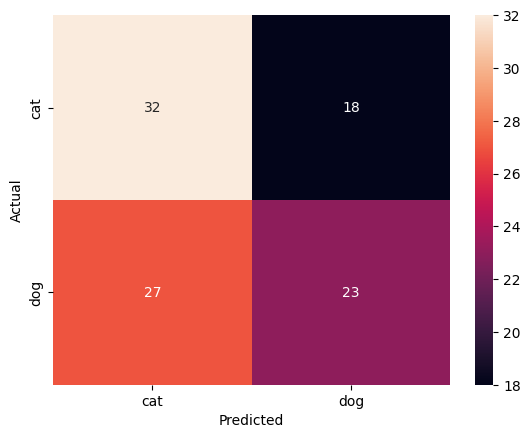

In [ ]:
predictions = cnn_model.predict(test_batches,verbose = 0)
predictions = np.round(predictions)
y_pred = np.argmax(predictions,axis = -1)


cm = confusion_matrix(test_batches.classes,y_pred)
classes = ['cat','dog']
sns.heatmap(cm,annot = True,xticklabels=classes,yticklabels = classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Using Pretrained Vgg16 model

In [ ]:
vgg16_model = tf.keras.applications.vgg16.VGG16()
print(vgg16_model)

In [ ]:
vgg16_model.summary()

In [ ]:
vgg16_model.non_trainable_weights

In [ ]:
import numpy as np
def count_params(model):
  print('Model ',model)
  all_trainable_params  = []
  all_non_trainable_params = []

  for v in model.trainable_weights:
    params = np.prod(v.shape.as_list())
    all_trainable_params.append(params)

  for v in model.non_trainable_weights:
    params2 = np.prod(v.shape.as_list())
    all_non_trainable_params.append(params2)

  return sum(all_trainable_params),sum(all_non_trainable_params)

In [ ]:
model = Sequential()
for layer in vgg16_model.layers[:-1]:
  model.add(layer)

for layer in model.layers:
  layer.trainable = False

model.add(Dense(units = 2,activation = 'softmax'))

In [ ]:
trainable_vgg16,non_trainable_vgg16 = count_params(vgg16_model)
trainable_my_model,non_trainable_my_model = count_params(model)

print("VGG16 ",trainable_vgg16,non_trainable_vgg16)
print("Model ",trainable_my_model,non_trainable_my_model)

In [ ]:
model.compile(optimizer=Adam(learning_rate = 0.0001),loss = 'categorical_crossentropy',metrics = ['accuracy'])
model.fit(x = train_batches,epochs = 5,verbose = 2,validation_data=valid_batches)


Epoch 1/5


KeyboardInterrupt: 

In [ ]:
model.history.history.get('accuracy')

In [ ]:
predictions = model.predict(test_batches,verbose = 2)
predictions = np.round(predictions)
y_pred = np.argmax(predictions,axis = -1)


In [ ]:



cm = confusion_matrix(test_batches.classes,y_pred)
classes = ['cat','dog']
sns.heatmap(cm,annot = True,xticklabels=classes,yticklabels = classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()